# DSCI 235 Final Project: Exploring Netflix Content and IMDb Scores

**Gavin Cooper**

GitHub: Link

### Introduction

For this project, I will be exploring two data sets that I got off of Kaggle relating to Netflix movies and TV Shows. The first data set contains information on Netflix's movie/TV show title, type, directors, genre, time put on Netflix, time produced, cast, and country of production. The second data set contains information on Netflix's movie/TV show title and it's corresponding IMDb score. I will be merging these two data sets to answer several questions surrounding type, genre, country of production, time periods, and how they relate to it's given IMDb score.

### Importing Libraries

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data Importing and Early Exploration

In [ ]:
#Loading in Netflix Titles dataset/the first data set

netflix = pd.read_csv('netflix_titles_1.csv')
print('Netflix titles shape:', netflix.shape)
netflix.info()

Netflix titles shape: (8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [155]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [156]:
#Loading in Netflix imdb dataset/the second data set


imdb = pd.read_csv('netflix_titles_2.csv')
print('IMDb dataset shape:', imdb.shape)
imdb.info()

IMDb dataset shape: (8807, 3)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        8807 non-null   str    
 1   show_id      8807 non-null   str    
 2   imdb_rating  6353 non-null   float64
dtypes: float64(1), str(2)
memory usage: 206.5 KB


In [157]:
imdb.head()

,title,show_id,imdb_rating
0,Dick Johnson Is Dead,s1,7.4
1,Blood & Water,s2,6.5
2,Ganglands,s3,7.0
3,Jailbirds New Orleans,s4,6.7
4,Kota Factory,s5,9.2


### Data Cleaning

In [158]:
print('Missing values in Netflix dataset:')
print(netflix.isnull().sum())
print()
print('Missing values in IMDb dataset:')
print(imdb.isnull().sum())

Missing values in Netflix dataset:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Missing values in IMDb dataset:
title             0
show_id           0
imdb_rating    2454
dtype: int64


In [159]:
netflix = netflix.dropna(subset=['date_added', 'rating','duration'])



netflix["director"] = Netflix['director'].fillna('Unknown')
netflix["country"] = Netflix['country'].fillna('unknown')
netflix["cast"] = Netflix['cast'].fillna('Unknown')


netflix["date_added"] = pd.to_datetime(netflix["date_added"].str.strip(),errors='coerce')
netflix["year_added"] = netflix["date_added"].dt.year

print("Netflix shape after data cleaning for NA's and dates: ", netflix.shape)

Netflix shape after data cleaning for NA's and dates:  (8790, 13)


In [160]:
mask_movies = netflix['type'] == 'Movie'

netflix.loc[mask_movies, 'duration_minutes'] = netflix.loc[mask_movies, 'duration'].str.replace(' min', '').astype(float)

mask_tv = netflix['type'] == 'TV Show'
netflix.loc[mask_tv, 'num_seasons'] = netflix.loc[mask_tv, 'duration'].str.replace(' Seasons?', '', regex=True).astype(float)

In [161]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_minutes,num_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,90.0,NaN
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,NaN,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,NaN,2.0


In [162]:
print('Duration Statistics for Movies (minutes): ', netflix.loc[mask_movies, 'duration_minutes'].describe())

print('Number of Seasons Statistics for TV Shows: ', netflix.loc[mask_tv, 'num_seasons'].describe())

Duration Statistics for Movies (minutes):  count    6126.000000
mean       99.584884
std        28.283225
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64
Number of Seasons Statistics for TV Shows:  count    2664.000000
mean        1.751877
std         1.550622
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: num_seasons, dtype: float64


In [163]:
#Standardizing titles for both data sets to prepare for merging them together

netflix['title'] = netflix['title'].str.strip().str.lower()
imdb['title'] = imdb['title'].str.strip().str.lower()

# Number of unique titles in each dataset before merging

num_unique_netflix =  netflix['title'].value_counts().count()
num_unique_imdb = imdb['title'].value_counts().count()
num_unique_netflix
print('Unique titles in Netflix dataset before merging: ', num_unique_netflix)
print('Unique titles in IMDb dataset before merging: ', num_unique_imdb)

Unique titles in Netflix dataset before merging:  8784
Unique titles in IMDb dataset before merging:  8801


### Merging the Datasets

In [164]:
df = pd.merge(netflix, imdb, on='title', how='outer', suffixes=('_netflix', '_imdb'))
df
titles_with_scores = df['imdb_rating'].notna().sum()
titles_without_scores = df['imdb_rating'].isna().sum()

print('Merged dataset shape:', df.shape)
print("Titles with IMDb ratings:", titles_with_scores)
print("Titles without IMDb ratings:", titles_without_scores)

Merged dataset shape: (8820, 17)
Titles with IMDb ratings: 6358
Titles without IMDb ratings: 2462


In [165]:

df_imdb_ratings = df.dropna(subset=['imdb_rating']).copy()

print("Titles with scores:", df_imdb_ratings.shape[0])

Titles with scores: 6358


### Cleaning Genre/listed_in Column

In [166]:
df_imdb_ratings["genre"] = df_imdb_ratings["listed_in"].str.split(',')
df_genre = df_imdb_ratings.explode('genre')
df_genre['genre'] = df_genre['genre'].str.strip()

num_unique_genres = len(df_genre['genre'].unique())

print("Unique genres in the dataset:", num_unique_genres)
#Top 5 genres in Data Set

top_5 = df_genre['genre'].value_counts().head(5)
print('\n')
print("Top 5 genres in the dataset:", top_5)


Unique genres in the dataset: 43


Top 5 genres in the dataset: genre
Dramas                    1829
International Movies      1790
Comedies                  1247
International TV Shows     857
Action & Adventure         656
Name: count, dtype: int64


### Question 1: What is the distribution of IMDb scores among different genres on Netflix?

I want to see how IMDb scores are spread across different genres to see if possibily some genres tend to score higher or lower. 

/var/folders/0z/qw4nf_q53f51b99p5x502zrc0000gn/T/ipykernel_29977/2531781501.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top_genres)


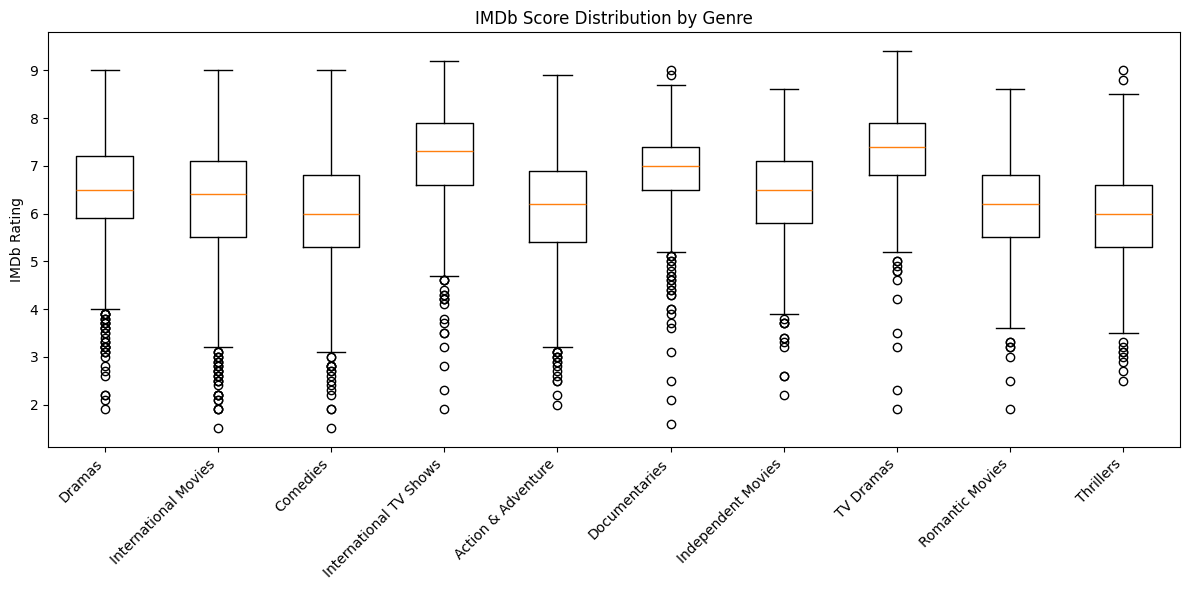

In [167]:


top_genres = df_genre['genre'].value_counts().head(10).index.tolist()
df_top_genre = df_genre[df_genre['genre'].isin(top_genres)]

data = []
for genre in top_genres:
    scores = df_top_genre[df_top_genre['genre'] == genre]['imdb_rating']
    data.append(scores)

plt.figure(figsize=(12, 6))
plt.boxplot(data, labels=top_genres)
plt.xticks(rotation=45, ha='right')
plt.title('IMDb Score Distribution by Genre')
plt.ylabel('IMDb Rating')
plt.tight_layout()
plt.show()



In [168]:
genre_stats = df_top_genre.groupby('genre')['imdb_rating'].aggregate(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False)
print("Summary Stats of Top 10 Genres \n", genre_stats)

Summary Stats of Top 10 Genres 
                             mean  median       std  count
genre                                                    
TV Dramas               7.309709     7.4  0.928003    515
International TV Shows  7.181914     7.3  1.023160    857
Documentaries           6.900626     7.0  0.885799    639
Dramas                  6.444560     6.5  1.027637   1829
Independent Movies      6.344828     6.5  1.041828    609
International Movies    6.237598     6.4  1.191548   1790
Romantic Movies         6.111680     6.2  1.003345    488
Action & Adventure      6.096646     6.2  1.189247    656
Thrillers               5.955724     6.0  1.098506    463
Comedies                5.945950     6.0  1.139301   1247


Discussion: The box plots and summary statistics give us a better insight on what genres tend to perform better than others based on their respective IMDb scores. Based on the results it reveals that TV Dramas and International TV Shows tend to recieve a IMDb score fairly higher than the other genres on average. Genre's that noticablly recieve a IMDb score lower than the rest are Thrillers and Comedies. Although this is the case on average, there is still relatively high variation, so we can't outright conclude that TV Dramas and International TV Shows will always perform better, and vice versa with Thrillers and Comedies. 

### Question 2: How has the distribution of TV and movie production across countries changed overtime on Netflix?

I noticed in the data set a lot of different countries that were involved with the producion of a movie. I find it valuable to look into how this has changed overtime, whether there has been an increase, decrease, or constant rate of countries contributing to TV and movie production on Netflix. 

In [169]:
#Note that there are sometimes multiple countries per title, so we will just take the first country listed as the primary country for that title for this analysis

df["primary_country"] = df['country'].str.split(',').str[0].str.strip()
top_countries = df[df['primary_country']!= 'unknown']['primary_country'].value_counts().head(10).index.tolist()
print("Top 10 content producing countries:", top_countries)

Top 10 content producing countries: ['United States', 'India', 'United Kingdom', 'Canada', 'Japan', 'France', 'South Korea', 'Spain', 'Mexico', 'Australia']


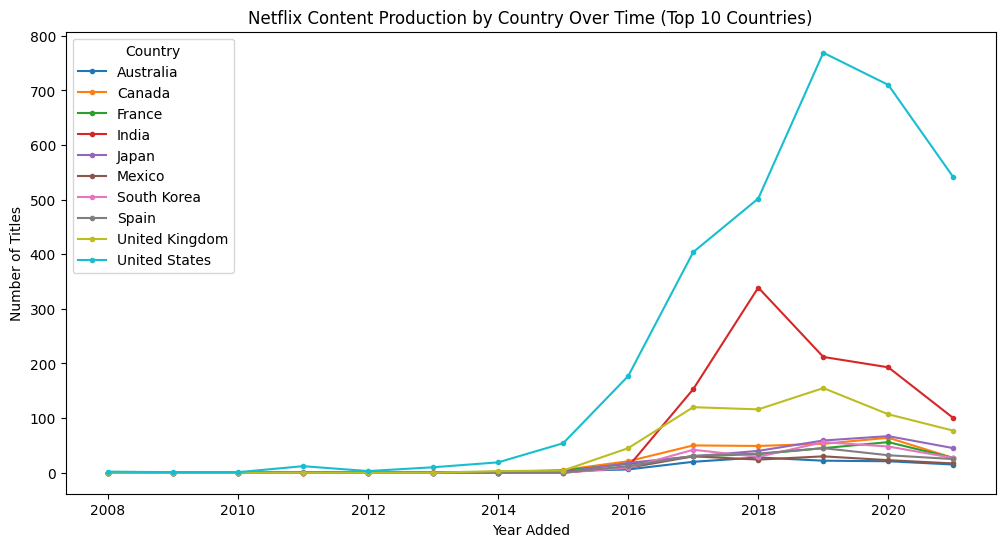

In [170]:
df_country = df[df['primary_country'].isin(top_countries)]

year_country = df_country.groupby(['year_added', 'primary_country']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
year_country.plot(ax = ax, marker = 'o', markersize = 3)
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles')
ax.set_title('Netflix Content Production by Country Over Time (Top 10 Countries)')
ax.legend(title='Country')
plt.show()

Discussion: Looking at the line plot, the number of titles produced for each country before 2015 was extremely low, but post 2015 and onward we can see that the United States have heavily dominated content production on Netflix. Although this is the case, we can see India made a strong attempt to try to catch up between 2016 - 2018 as the rate of there increase in content production on Netflix increased at a rate similar to the United States. Third place was the United Kingdom where they have remained fairly stagnet between 2017-2021. A key thing to note is the sharp decline in content production on netflix starting in 2018 in India, but for US and UK it primarily began in 2019. This rate for the top 3 countries is continuously declining for the rest of the remaining years in the dataset, and although we don't know for certain, it is likely that COVID-19 caused this affect. COVID-19 around the world decreased consumption and investment which could have affected the content production for Netflix. The other remaining 7 countries have definitely increased their content production on Netflix overtime, but compared to the top 3: United States, UK, and India, they have only contributed a little to the overal content production surge on Netflix. 

### Question 3: Do certain countries produce higher IMDb rated content compared to others on Netflix?

Because of the previous question I wanted to know more about the difference between countries. The United States dominates in production, but I want to examine if certain countries create better quality even if their quanitity is lower in comparison to the United States. 

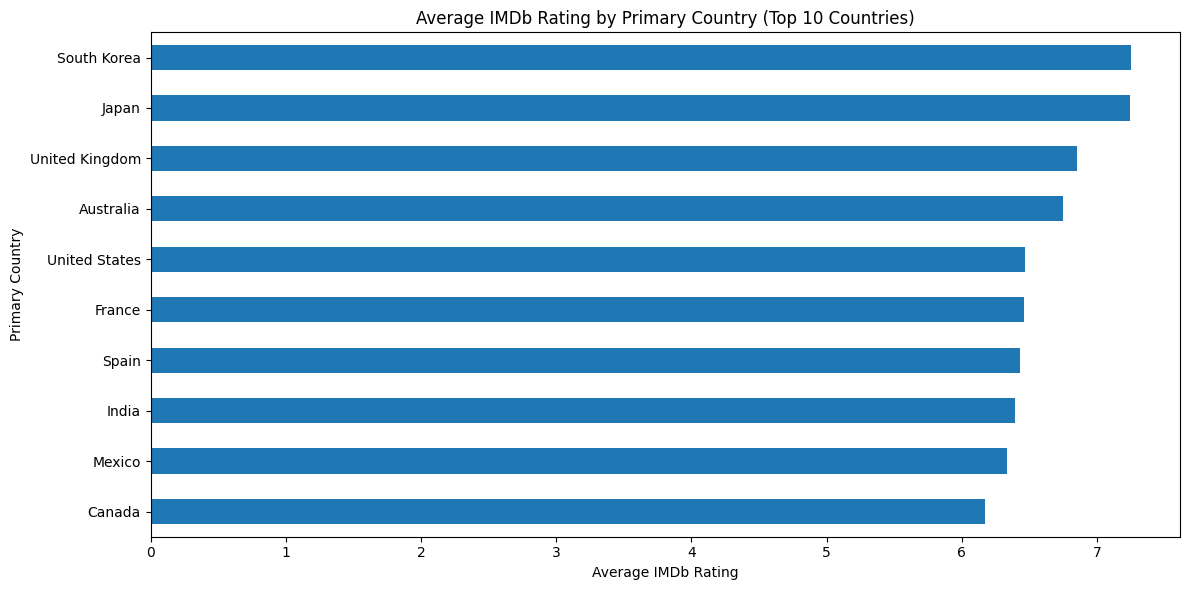

In [171]:
df_imdb_ratings["primary_country"] = df_imdb_ratings['country'].str.split(',').str[0].str.strip()

df_imdb_rating_2 = df_imdb_ratings[df_imdb_ratings['primary_country'].isin(top_countries)]

country_mean = df_imdb_rating_2.groupby('primary_country')['imdb_rating'].aggregate(['mean', 'count']).sort_values(by='mean', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
country_mean['mean'].plot(kind='barh', ax=ax)
ax.set_xlabel('Average IMDb Rating')
ax.set_ylabel('Primary Country')
ax.set_title('Average IMDb Rating by Primary Country (Top 10 Countries)')
plt.tight_layout()
plt.show()

In [173]:
print("Summary Stats: \n", country_mean)

Summary Stats: 
                      mean  count
primary_country                 
Canada           6.170874    206
Mexico           6.334483     87
India            6.395315    683
Spain            6.433051    118
France           6.457962    157
United States    6.470337   2734
Australia        6.748864     88
United Kingdom   6.854990    511
Japan            7.245570    158
South Korea      7.252414    145


Discussion: There are noticable differences in average IMDb scores across the top 10 content production countries. Based on the results the countries that tend to have a lower quanitity in production on Netflix had a higher average IMDb score. This could be due to countries that produce higher quanities of content on Netflix, such as the United States and India, have more variability in the quality of their production. While some countries have smaller but more curated catalogs on Netflix which results in higher average IMDb scores. The UK is somewhat of an outlier with having a high amount of productions on netflix and also attaining a high average IMDb score. This may reflect that the UK heavily prioritizes the quality of each of their productions regardless of the quantity they are able to produce. 

### Question 4: has the average IMDb score on Netflix increased or decreased over time?

There has been a surge of content production on Netflix over time, but has the quality remained relatively the same or has it changed due to the increase in production. 

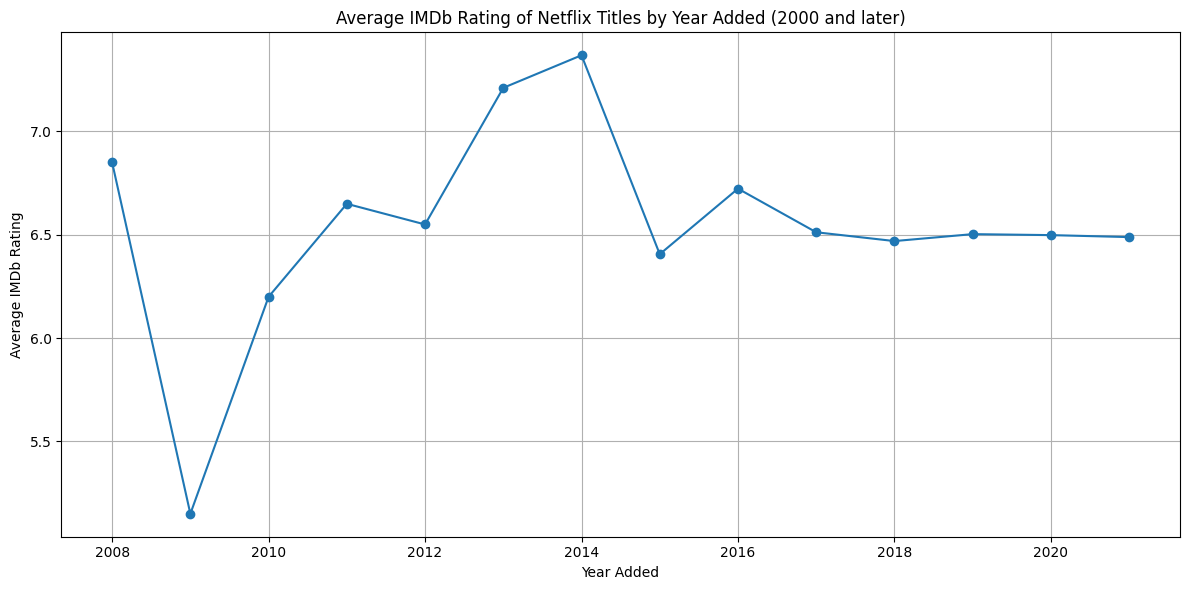

In [175]:
df_time = df_imdb_ratings[df_imdb_ratings["year_added"] >= 2000]

yearly_avg = df_time.groupby('year_added')['imdb_rating'].mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.xlabel('Year Added')
plt.ylabel('Average IMDb Rating')
plt.title('Average IMDb Rating of Netflix Titles by Year Added (2000 and later)')
plt.grid()
plt.tight_layout()
plt.show()

Discussion: From the plot given we can see that in 2008 is starts high and drastically drops in 2009. Although this is one of the biggest changes in average IMDb score from one year to another, it's wise to take into account that there was a lot less titles on Netflix during these years. There was a steady cliimb from 2010 to 2014, which can represent Netflix becoming more popular, therefore they were more selective when it came to adding certain titles onto their platform. It peaks in 2014 and drops to a a more steady rate where it has been relatively consistent up to 2021. We can takeaway that as Netflix scaled up to be the powerful platform they are today, their library matured into quantity over quality. 

### Question 5: Is there correlation between runtime and IMDb scores on Netflix?

I want to explore a possibilty of correlation of runtime of movies and IMDb scores, as it can give good insite on how IMDb scores are curated and who is curating them.

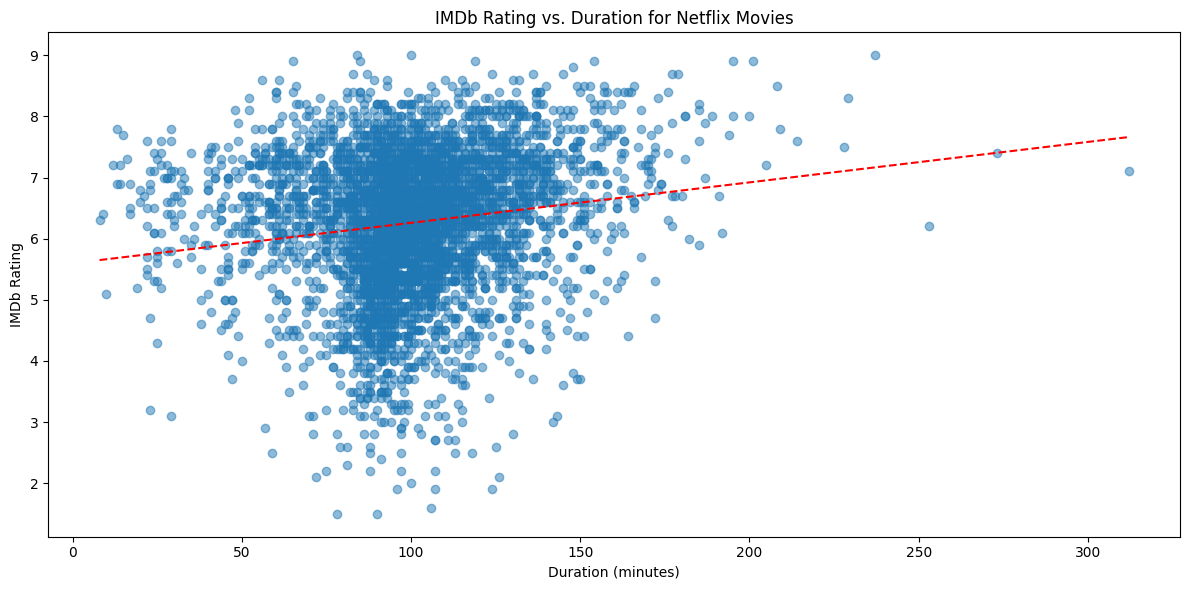

In [181]:
df_movies = df_imdb_ratings[df_imdb_ratings['type'] == 'Movie'].dropna(subset=['duration_minutes','imdb_rating'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df_movies['duration_minutes'], df_movies['imdb_rating'], alpha=0.5)
a = np.polyfit(df_movies['duration_minutes'], df_movies['imdb_rating'], 1)
b = np.poly1d(a)

fit_line = np.linspace(df_movies['duration_minutes'].min(), df_movies['duration_minutes'].max(), 100)
ax.plot(fit_line, b(fit_line), color='red', linestyle='--', label='Trend Line')



ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('IMDb Rating')
ax.set_title('IMDb Rating vs. Duration for Netflix Movies')
plt.tight_layout()
plt.show()
ax.legend()

In [183]:
pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.2/28.2 MB 6.1 MB/s  0:00:04m0:00:0100:01

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [189]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(df_movies['duration_minutes'], df_movies['imdb_rating'])
print(f"Pearson correlation coefficient: {correlation:.2f}, p-value: {p_value:.2e}")

Pearson correlation coefficient: 0.15, p-value: 5.64e-25


Discussion: Based on the plot and the results from the statistical test I ran to test whether there was significant evidence of a linear relationship between movie run time and IMDb scores, there is sufficient statistical evidence to conlude that there is a linear relationship between the two variables. Because, assuming a alpha level of 0.05, the p-value is well below the alpha level. Although this is the case the correlation coefficent is relatively low due to the high variation within the data, as seen in the plot. The low p-value may be partially due to the test having high power because of how large the sample is, therefore any meaningful correlation will be captured by the test. 

### Question 6: How do IMDb scores vary across different content ratings/rating on Netflix?

I wanted to explore how different content ratings/rating differ by there mean IMDb score. Whether some ratings tend to recieve higher or lower scores on average.

rating
NR          6.649020
TV-PG       6.602465
TV-14       6.585319
TV-MA       6.561142
TV-G        6.512821
TV-Y7       6.439444
G           6.394118
TV-Y        6.392814
PG-13       6.373423
R           6.358587
PG          6.163750
NC-17       5.500000
UR          5.200000
TV-Y7-FV    3.900000
Name: imdb_rating, dtype: float64


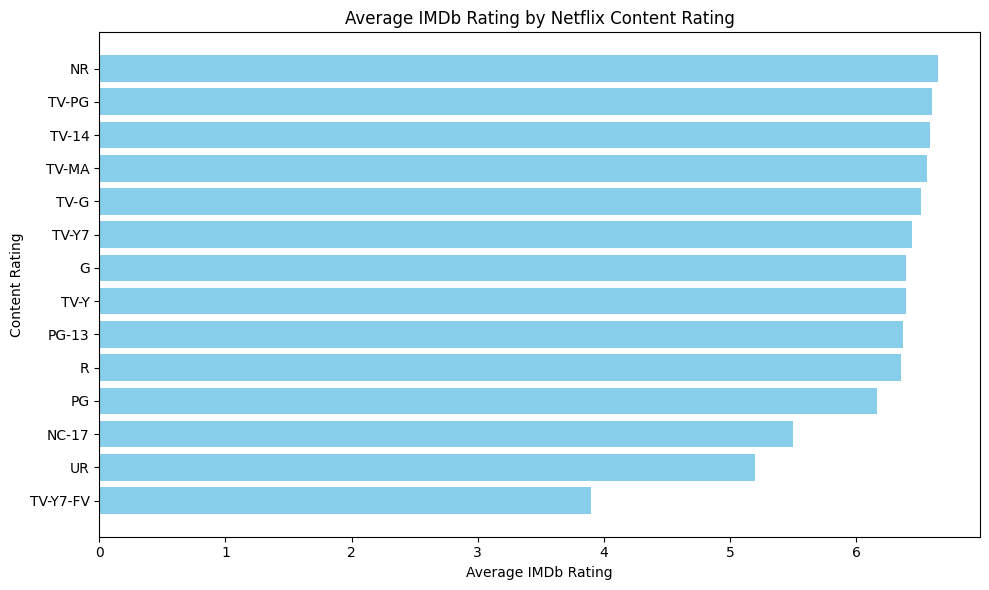

In [202]:
print(df_imdb_ratings.groupby('rating')['imdb_rating'].mean().sort_values(ascending=False))

rating_stats = df_imdb_ratings.groupby('rating')['imdb_rating'].aggregate(['mean', 'count']). sort_values(by = 'mean',ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(rating_stats.index, rating_stats['mean'], color='skyblue')
plt.xlabel('Average IMDb Rating')
plt.ylabel('Content Rating')
plt.title('Average IMDb Rating by Netflix Content Rating')
plt.tight_layout()
plt.show()  




Discussion: Based on the output of mean IMDb rating by content rating, most of the rating had similar mean IMDb scores outside of NC-17, UR, and TV-Y7-FV which performed marginally worse than the other content ratings on average. These content ratings likely have very small sample sizes, so they can be skewed to have a lower average. A takeaway is content rating has some relationship with IMDb score, but genre is a better metric in predicting how well something will do.  

### Last Analysis: Movies vs. TV Shows on Netflix and their comparison of IMDb scores

/var/folders/0z/qw4nf_q53f51b99p5x502zrc0000gn/T/ipykernel_29977/4187842949.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(type_data, labels=['Movie', 'TV Show'])


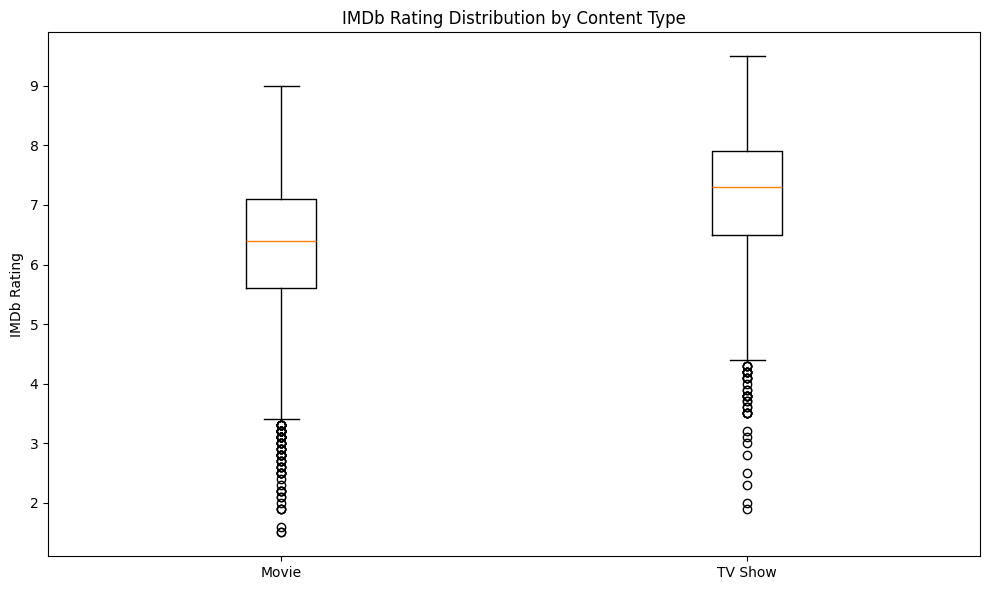

In [204]:

type_data = [df_imdb_ratings[df_imdb_ratings['type'] == i]['imdb_rating'] for i in ['Movie', 'TV Show']]
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(type_data, labels=['Movie', 'TV Show'])
ax.set_title('IMDb Rating Distribution by Content Type')
ax.set_ylabel('IMDb Rating')
plt.tight_layout()
plt.show()


Discussion: From the plot, we can see that TV shows out perform Movies on Netflix when it comes to IMDb ratings. This can be due to industry standards when it comes to the production of TV shows and Movies, or a skew in how IMDb gives out their scores. They may often awards TV shows higher rankings even if a movie has a similar quality level. This may happen due to TV shows having a lot more runtime, where mistakes may be covered up by a lot of good quality in other parts of the show. 

### Conclusion

Through my analysis I explored many question surrounding Netflix content and their respective IMDb scores. My key findings from my analysis include that there are genre differences, country differences, time trend dependencies, runtime correlation, quanity vs. quanity over time differences by country, and content rating difference when it comes to their respective IMDb scores. Some genres tend to recieve a higher IMDb score on average, such as TV dramas and Interanational TV. Some countries on average had a higher IMDb score compared to other countries, such as South Korea, Japan, and the UK. Where South Korea and Japan had higher IMDb scores becauase of their TV shows and movies being curated with lower quanitiy on Netflix. While the UK was a massive outlier balancing quality and quanitiy. Overtime, the U.S has dominated the market on Netflix with having more productions than any other country by a large metric. India was in second place in production on Netflix and the UK was third. A massive finding was the correlation between runtime and IMDb scores for movies, as this suprised even myself. There was a linear correlation between the two metrics, which may be caused by longer movies having a higher quality standards compared to shorter movies on Netflix. Overall, this analysis demostrates that the Netflix catalog is diverse in quanlity across multiple factors. No single factor like genre, content rating, country production, or runtime garuntees a high IMDb score, but there are certain patterns that are demonstrated in my analysis. Future work that would improve upon my analysis would be building models and statistcally testing more of the factors to try an better pinpoint what is driving higher or lower IMDb scores. 